# 03 — Score de risque d'inondation composite par commune

**Principe (z-scores combinés, comme pour le score de vulnérabilité UEMOA)**
1. Pour chaque indicateur, on calcule un **z-score** sur les 53 communes : z = (valeur − moyenne) / écart-type. Un z de +1 signifie « un écart-type au-dessus de la moyenne régionale ».
2. Chaque indicateur est **orienté** pour que « z élevé = plus de risque ».
3. On borne les z entre -3 et +3, pour qu'une commune extrême ne domine pas tout.
4. Score composite = **moyenne des z** (poids égaux), ramenée ensuite sur **0-100** pour l'affichage.

**Le score est relatif.** Il classe les communes entre elles au sein de la région de Dakar. Ce n'est pas une probabilité d'inondation.

**Indicateurs retenus** (validés le 27/09/2026)

| Indicateur | Source | Orientation | Poids |
|---|---|---|---|
| Altitude médiane du sol approché | Copernicus DEM (notebook 02) | plus bas = plus de risque | 1/3 |
| % de surface en cuvette (échelle ≈ 1 km) | Copernicus DEM (notebook 02) | plus = plus de risque | 1/3 |
| % d'eau stagnante après pluie (échelle log) | Sentinel-1 (notebook 02) | plus = plus de risque | 1/3 |

**Exclus, volontairement :**
- **Précipitations CHIRPS** : aucun pixel valide sur 13 communes, dont 11 prioritaires.
- **Pente** : le DEM inclut les bâtiments, donc en ville la pente mesure les toits, pas le relief.

**Fichiers produits :**
- `data/processed/score_risque_communes.csv`
- `data/processed/score_risque_communes.geojson` : même contenu avec les contours, **pour l'appli**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROJET = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = PROJET / "data" / "processed"
OUTPUTS = PROJET / "outputs"

# Fichiers produits par les notebooks 00 et 02
communes = gpd.read_file(PROCESSED / "communes_dakar_terre.geojson")
eau = pd.read_csv(PROCESSED / "score_eau_satellite.csv")
topo = pd.read_csv(PROCESSED / "topo_communes.csv")

df = (communes.merge(eau[["osm_id", "pct_eau_stagnante_moyen", "nb_dates_sup_1pct", "pct_eau_permanente"]], on="osm_id")
              .merge(topo[["osm_id", "alt_mediane_m", "pct_sous_5m", "pct_depression", "pente_moy_deg"]], on="osm_id"))
assert len(df) == len(communes) == 53, "Des communes n'ont pas été appariées"
print(len(df), "communes avec toutes les données")

53 communes avec toutes les données


## 1. Indicateurs orientés

- **Altitude :** on prend l'opposé de l'altitude médiane, pour qu'une commune basse ait une valeur élevée.
- **Eau stagnante :** la distribution est très asymétrique. La plupart des communes sont à 0 et quelques-unes vont jusqu'à 0,8 %. On applique log10(x + 0,01), où 0,01 % est l'ordre de grandeur de la plus petite valeur détectée. Sans ça, deux ou trois communes périurbaines écraseraient toutes les autres.

In [2]:
INDICATEURS = {
    "ind_altitude_basse": -df["alt_mediane_m"],
    "ind_cuvettes": df["pct_depression"],
    "ind_eau_s1": np.log10(df["pct_eau_stagnante_moyen"] + 0.01),
}
for nom, valeurs in INDICATEURS.items():
    df[nom] = valeurs

# Redondance : deux indicateurs très corrélés compteraient double
df[list(INDICATEURS)].corr(method="spearman").round(2)

,ind_altitude_basse,ind_cuvettes,ind_eau_s1
ind_altitude_basse,1.00,-0.32,0.14
ind_cuvettes,-0.32,1.00,0.03
ind_eau_s1,0.14,0.03,1.00


## 2. Z-scores et score composite

In [3]:
def zscore(s):
    return ((s - s.mean()) / s.std(ddof=0)).clip(-3, 3)

for nom in INDICATEURS:
    df["z_" + nom.removeprefix("ind_")] = zscore(df[nom])

Z = ["z_altitude_basse", "z_cuvettes", "z_eau_s1"]

def score_0_100(colonnes):
    brut = df[colonnes].mean(axis=1)
    return (100 * (brut - brut.min()) / (brut.max() - brut.min())).round(1)

df["score_risque"] = score_0_100(Z)
df["rang"] = df["score_risque"].rank(ascending=False, method="min").astype(int)

# 5 classes de taille égale (quintiles) : chaque classe contient environ 1/5 des communes
df["classe_risque"] = pd.qcut(df["score_risque"].rank(method="first"), 5,
                              labels=["Très faible", "Faible", "Moyen", "Élevé", "Très élevé"])
df.sort_values("rang")[["rang", "commune", "zone_prioritaire", "score_risque", "classe_risque"] + Z].head(15).round(2)

,rang,commune,zone_prioritaire,score_risque,classe_risque,z_altitude_basse,z_cuvettes,z_eau_s1
38,1,Pikine Ouest,Pikine,100.0,Très élevé,1.28,1.85,0.58
27,2,Malika,NaN,95.1,Très élevé,0.90,0.96,1.50
43,3,Bargny,NaN,94.1,Très élevé,0.59,0.81,1.88
51,4,Tivaouane Peulh-Niaga,NaN,91.1,Très élevé,0.82,-0.03,2.27
20,5,Medina Gounass,Guédiawaye,86.6,Très élevé,0.70,3.00,-0.95
23,6,Wakhinane Nimzatt,Guédiawaye,84.1,Très élevé,0.50,0.54,1.53
21,7,Ndiarème Limamoulaye,Guédiawaye,79.1,Très élevé,0.31,0.77,1.13
1,8,Cambérène,NaN,74.2,Très élevé,0.42,-0.39,1.82
28,9,Yeumbeul Nord,Yeumbeul,73.2,Très élevé,0.60,0.25,0.94
52,10,Yenne,NaN,72.0,Très élevé,-1.26,1.51,1.45


## 3. Contrôle de robustesse

On recalcule le classement avec deux variantes :
- **B, sans Sentinel-1** : altitude et cuvettes seulement ;
- **C, altitude seule**.

Une commune dont le rang varie peu d'une variante à l'autre a un classement **robuste**. Une commune qui change beaucoup de rang doit être présentée avec prudence, car son score dépend d'un choix de méthode.

In [4]:
df["rang_sans_s1"] = score_0_100(["z_altitude_basse", "z_cuvettes"]).rank(ascending=False, method="min").astype(int)
df["rang_altitude_seule"] = score_0_100(["z_altitude_basse"]).rank(ascending=False, method="min").astype(int)
rangs = df[["rang", "rang_sans_s1", "rang_altitude_seule"]]
df["ecart_rang_max"] = rangs.max(axis=1) - rangs.min(axis=1)
df["classement_robuste"] = df["ecart_rang_max"] <= 10

print("Corrélation des rangs (Spearman) :")
print(rangs.corr(method="spearman").round(2))
print(f"\nCommunes au classement robuste (écart ≤ 10 rangs) : {df.classement_robuste.sum()} / {len(df)}")

Corrélation des rangs (Spearman) :
                     rang  rang_sans_s1  rang_altitude_seule
rang                 1.00          0.77                 0.47
rang_sans_s1         0.77          1.00                 0.54
rang_altitude_seule  0.47          0.54                 1.00

Communes au classement robuste (écart ≤ 10 rangs) : 13 / 53


In [5]:
(df[df.prioritaire]
 .sort_values("rang")
 [["rang", "commune", "zone_prioritaire", "score_risque", "classe_risque", "alt_mediane_m",
   "pct_depression", "pct_eau_stagnante_moyen", "rang_sans_s1", "rang_altitude_seule", "classement_robuste"]]
 .reset_index(drop=True))

,rang,commune,zone_prioritaire,score_risque,classe_risque,alt_mediane_m,pct_depression,pct_eau_stagnante_moyen,rang_sans_s1,rang_altitude_seule,classement_robuste
0,1,Pikine Ouest,Pikine,100.0,Très élevé,2.34,44.42,0.07,2,1,True
1,5,Medina Gounass,Guédiawaye,86.6,Très élevé,6.84,58.23,0.00,1,17,False
2,6,Wakhinane Nimzatt,Guédiawaye,84.1,Très élevé,8.38,30.10,0.28,10,24,False
3,7,Ndiarème Limamoulaye,Guédiawaye,79.1,Très élevé,9.89,32.57,0.16,9,29,False
4,9,Yeumbeul Nord,Yeumbeul,73.2,Très élevé,7.66,26.92,0.12,12,20,False
5,15,Thiaroye-Gare,Pikine,61.1,Élevé,7.71,11.04,0.28,37,22,False
6,16,Tivaouane Diacksao,Pikine,60.5,Élevé,5.84,12.75,0.15,27,10,False
7,19,Djidah Thiaroye Kaw,Pikine,53.2,Élevé,7.93,32.27,0.00,7,23,False
8,21,Golf Sud,Guédiawaye,51.4,Élevé,14.03,28.27,0.03,23,38,False
9,22,Mbao,Pikine,51.1,Moyen,6.21,17.06,0.03,24,12,False


## 4. Enregistrement

Le fichier contient, pour chaque commune, les valeurs brutes (lisibles dans l'appli), les z-scores, le score, la classe et le contrôle de robustesse.

In [6]:
df["alerte_detection_s1"] = np.where(
    df["pct_eau_stagnante_moyen"] == 0,
    "Aucune eau détectée par satellite : peut refléter la limite du radar en bâti dense, pas l'absence d'inondation",
    "")

colonnes = ["osm_id", "commune", "departement", "zone_prioritaire", "prioritaire",
            "score_risque", "classe_risque", "rang",
            "alt_mediane_m", "pct_sous_5m", "pct_depression", "pct_eau_stagnante_moyen", "nb_dates_sup_1pct",
            "pct_eau_permanente", "pente_moy_deg",
            "z_altitude_basse", "z_cuvettes", "z_eau_s1",
            "rang_sans_s1", "rang_altitude_seule", "ecart_rang_max", "classement_robuste",
            "alerte_detection_s1", "surface_km2"]
sortie = df[colonnes + ["geometry"]].sort_values("rang").reset_index(drop=True)
sortie["classe_risque"] = sortie["classe_risque"].astype(str)
for c in ["z_altitude_basse", "z_cuvettes", "z_eau_s1"]:
    sortie[c] = sortie[c].round(3)

# Le découpage sur la côte (notebook 00) peut laisser des points ou lignes isolés à côté du polygone
# (cas de Dakar-Plateau). Les cartes web n'affichent que des (Multi)Polygon : on ne garde que les surfaces.
from shapely.geometry import MultiPolygon

def polygones_seuls(g):
    if g.geom_type in ("Polygon", "MultiPolygon"):
        return g
    parts = [p for p in getattr(g, "geoms", []) if p.geom_type in ("Polygon", "MultiPolygon")]
    parts = [q for p in parts for q in (p.geoms if p.geom_type == "MultiPolygon" else [p])]
    return parts[0] if len(parts) == 1 else MultiPolygon(parts)

sortie["geometry"] = sortie.geometry.apply(polygones_seuls)
assert sortie.geom_type.isin(["Polygon", "MultiPolygon"]).all()

sortie.drop(columns="geometry").to_csv(PROCESSED / "score_risque_communes.csv", index=False, encoding="utf-8")
sortie.to_file(PROCESSED / "score_risque_communes.geojson", driver="GeoJSON")
print("Enregistrés : score_risque_communes.csv et score_risque_communes.geojson")

Enregistrés : score_risque_communes.csv et score_risque_communes.geojson


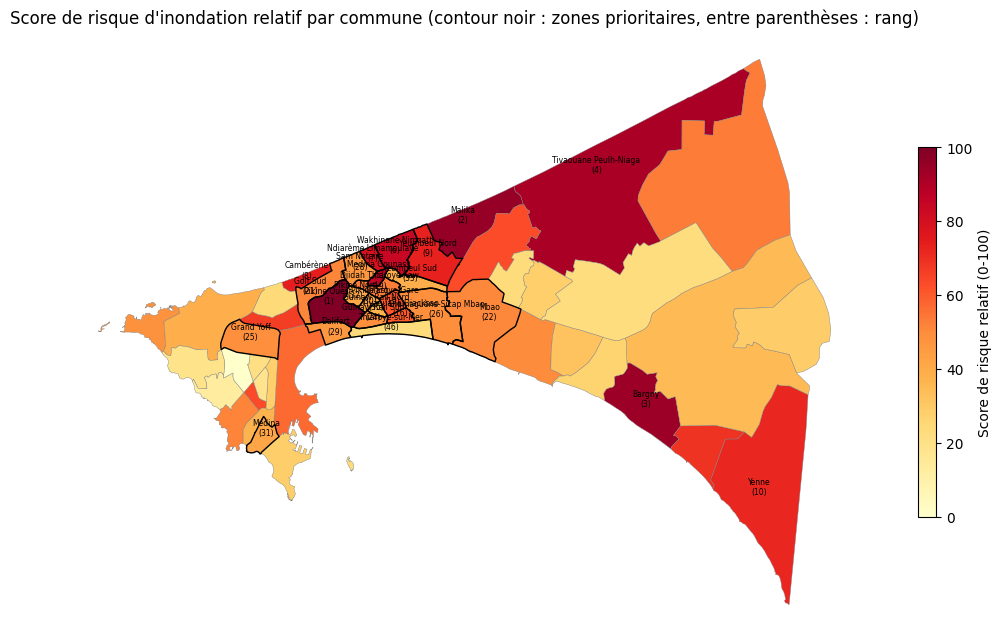

In [7]:
fig, ax = plt.subplots(figsize=(13, 8))
sortie.plot(ax=ax, column="score_risque", cmap="YlOrRd", legend=True, edgecolor="grey", linewidth=0.3,
            legend_kwds={"label": "Score de risque relatif (0-100)", "shrink": 0.6})
sortie[sortie.prioritaire].boundary.plot(ax=ax, color="black", linewidth=1)
for _, c in sortie[sortie.prioritaire | (sortie.rang <= 10)].iterrows():
    p = c.geometry.representative_point()
    ax.annotate(f"{c.commune}\n({c.rang})", (p.x, p.y), fontsize=5.5, ha="center")
ax.set_title("Score de risque d'inondation relatif par commune (contour noir : zones prioritaires, entre parenthèses : rang)")
ax.set_axis_off()
plt.savefig(OUTPUTS / "apercu_score_risque.png", dpi=150, bbox_inches="tight")
plt.show()

## Limites du score

- **Score relatif** : il classe les 53 communes entre elles. Une commune en « Très faible » peut connaître des inondations. Elle est simplement moins exposée que les autres selon ces indicateurs.
- **Deux indicateurs sur trois viennent du même DEM** (altitude et cuvettes). Le score est donc surtout **topographique** : il dit où l'eau *devrait* s'accumuler, pas où elle s'accumule réellement.
- L'indicateur Sentinel-1 est faible et **aveugle au bâti dense** (voir notebook 02). La colonne `alerte_detection_s1` le signale pour les communes à 0 %.
- **Facteurs importants absents** : drainage et assainissement (canaux, bassins de rétention du PROGEP), nappe phréatique affleurante (cause majeure des inondations durables à Pikine et Guédiawaye), imperméabilisation des sols, densité de population. Le score mesure l'**aléa physique**, pas la vulnérabilité des habitants.
- **Pas de validation** avec des inondations observées. La prochaine étape serait une comparaison avec des signalements (presse, ONAS, BNSP), des photos, ou les cartes de l'UNOSAT ou du Copernicus EMS si elles existent pour Dakar.